# LAND-style figures adapted to American Samoa

This notebook recreates the most relevant figure types from `LocationAgnosticNeuralDownscaling/results/figures` using the retained American Samoa outputs.

The original code was traced mainly to:

- `results/plots.ipynb`: station maps, comprehensive map, reanalysis extent, DEM examples;
- `results/topography_alignment.ipynb`: rainfall-elevation gradient figure;
- `results/main_results_I.ipynb` and `main_results_II.ipynb`: station climatology and Q-Q figures;
- `results/results_III.ipynb`: absolute and percent-change time series;
- `results/rah_comparison.ipynb` and `results/climatology.py`: wet/dry climatology-map layout.

The Hawaii GCM future-projection figures are not reproduced because this repository has no American Samoa GCM downscaling output.


In [1]:
import json
import sys
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import rasterio
import xarray as xr
from scipy.interpolate import griddata
from scipy.stats import linregress

warnings.filterwarnings('ignore')
PACKAGE_DIR = Path.cwd()
if not (PACKAGE_DIR / 'config.py').exists():
    if (PACKAGE_DIR / 'LAND_AS').exists():
        PACKAGE_DIR = PACKAGE_DIR / 'LAND_AS'
    elif (PACKAGE_DIR.parent / 'config.py').exists():
        PACKAGE_DIR = PACKAGE_DIR.parent
REPO_ROOT = PACKAGE_DIR.parent
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

from LAND_AS import config

plt.rcParams.update({'figure.dpi': 120, 'savefig.dpi': 180, 'font.size': 9})
FIG_DIR = PACKAGE_DIR / 'output' / 'figures' / 'land_style'
FIG_DIR.mkdir(parents=True, exist_ok=True)

meta = pd.read_csv(REPO_ROOT / 'raw_data' / 'AS' / 'station_locations.csv').rename(columns={'Station': 'station', 'LAT': 'lat', 'LONG': 'lon', 'elev_ft': 'elevation_ft'})
for col in ['lat', 'lon', 'elevation_ft']:
    meta[col] = pd.to_numeric(meta[col], errors='coerce')
dataset = np.load(config.DATASET_PATH, allow_pickle=True)
stations = dataset['stations'].astype(str)
years = dataset['years'].astype(int)
months = dataset['months'].astype(int)
days = dataset['days'].astype(int)
rain = dataset['rainfall_mm_raw'].astype(float)
test_mask = np.isin(stations, config.TEST_STATIONS) & (years > config.TRAIN_YEAR_END)
train_mask = (~np.isin(stations, config.TEST_STATIONS)) & (years <= config.TRAIN_YEAR_END)
meta['role'] = np.where(meta['station'].isin(config.TEST_STATIONS), 'test', 'train')
mean_rain = pd.DataFrame({'station': stations, 'rain': rain}).groupby('station')['rain'].mean()
meta['mean_weekly_rain_mm'] = meta['station'].map(mean_rain)
print('Stations:', meta.shape[0], 'samples:', len(rain), 'test:', test_mask.sum())

Stations: 27 samples: 9459 test: 837


## Figure provenance map

This table maps each generated file to the original figure family that inspired it.


In [2]:
trace = pd.DataFrame([
    ('station_locations.svg', 'station_locations.svg', 'plots.ipynb'),
    ('training_locations.svg', 'training_locations.svg', 'plots.ipynb'),
    ('comprehensive_map.svg', 'comprehensive_map.svg', 'plots.ipynb + visualization_utils.comprehensive_map'),
    ('reanalysis_extent.svg', 'reanalysis_extent.svg', 'plots.ipynb'),
    ('tutuila_dem_example.svg', 'oahu_dem_example.svg', 'plots.ipynb'),
    ('tutuila_dem_example_extracted_dems.svg', 'oahu_dem_example_extracted_dems.svg', 'plots.ipynb'),
    ('historical_climatology_observed_wet.svg', 'historical_climatology_*_wet.svg', 'rah_comparison.ipynb + climatology.py'),
    ('historical_climatology_observed_dry.svg', 'historical_climatology_*_dry.svg', 'rah_comparison.ipynb + climatology.py'),
    ('Ia_climatology.svg', 'Ia_climatology.svg', 'main_results_I.ipynb'),
    ('IIa_climatology.svg', 'IIa_climatology.svg', 'main_results_II.ipynb'),
    ('qq_IIa.svg', 'qq_IIa.svg', 'main_results_II.ipynb'),
    ('FigGradientComparisonV2.svg', 'FigGradientComparisonV2.svg', 'topography_alignment.ipynb'),
    ('timeseries_absolute.svg', 'timeseries_absolute.svg', 'results_III.ipynb'),
    ('timeseries_pchange.svg', 'timeseries_pchange.svg', 'results_III.ipynb'),
], columns=['generated_file', 'original_figure', 'traced_source'])
display(trace)


,generated_file,original_figure,traced_source
0,station_locations.svg,station_locations.svg,plots.ipynb
1,training_locations.svg,training_locations.svg,plots.ipynb
2,comprehensive_map.svg,comprehensive_map.svg,plots.ipynb + visualization_utils.comprehensiv...
3,reanalysis_extent.svg,reanalysis_extent.svg,plots.ipynb
4,tutuila_dem_example.svg,oahu_dem_example.svg,plots.ipynb
5,tutuila_dem_example_extracted_dems.svg,oahu_dem_example_extracted_dems.svg,plots.ipynb
6,historical_climatology_observed_wet.svg,historical_climatology_*_wet.svg,rah_comparison.ipynb + climatology.py
7,historical_climatology_observed_dry.svg,historical_climatology_*_dry.svg,rah_comparison.ipynb + climatology.py
8,Ia_climatology.svg,Ia_climatology.svg,main_results_I.ipynb
9,IIa_climatology.svg,IIa_climatology.svg,main_results_II.ipynb


In [3]:
dem_path = REPO_ROOT / 'raw_data' / 'AS' / 'DEM' / '10m_tutuila_3band.tif'
with rasterio.open(dem_path) as src:
    transform = src.transform
    elev_full = src.read(1)
    bounds = src.bounds
step = max(1, elev_full.shape[0] // 900)
elev = elev_full[::step, ::step].astype(float)
height, width = elev.shape
xs = np.linspace(bounds.left, bounds.right, width)
ys = np.linspace(bounds.bottom, bounds.top, height)
extent = [bounds.left, bounds.right, bounds.bottom, bounds.top]
print('DEM shape:', elev_full.shape, 'display shape:', elev.shape, 'bounds:', bounds)


DEM shape: (1562, 3256) display shape: (1562, 3256) bounds: BoundingBox(left=-170.847006549233, bottom=-14.374207000544647, right=-170.54552507619297, top=-14.229577374964647)


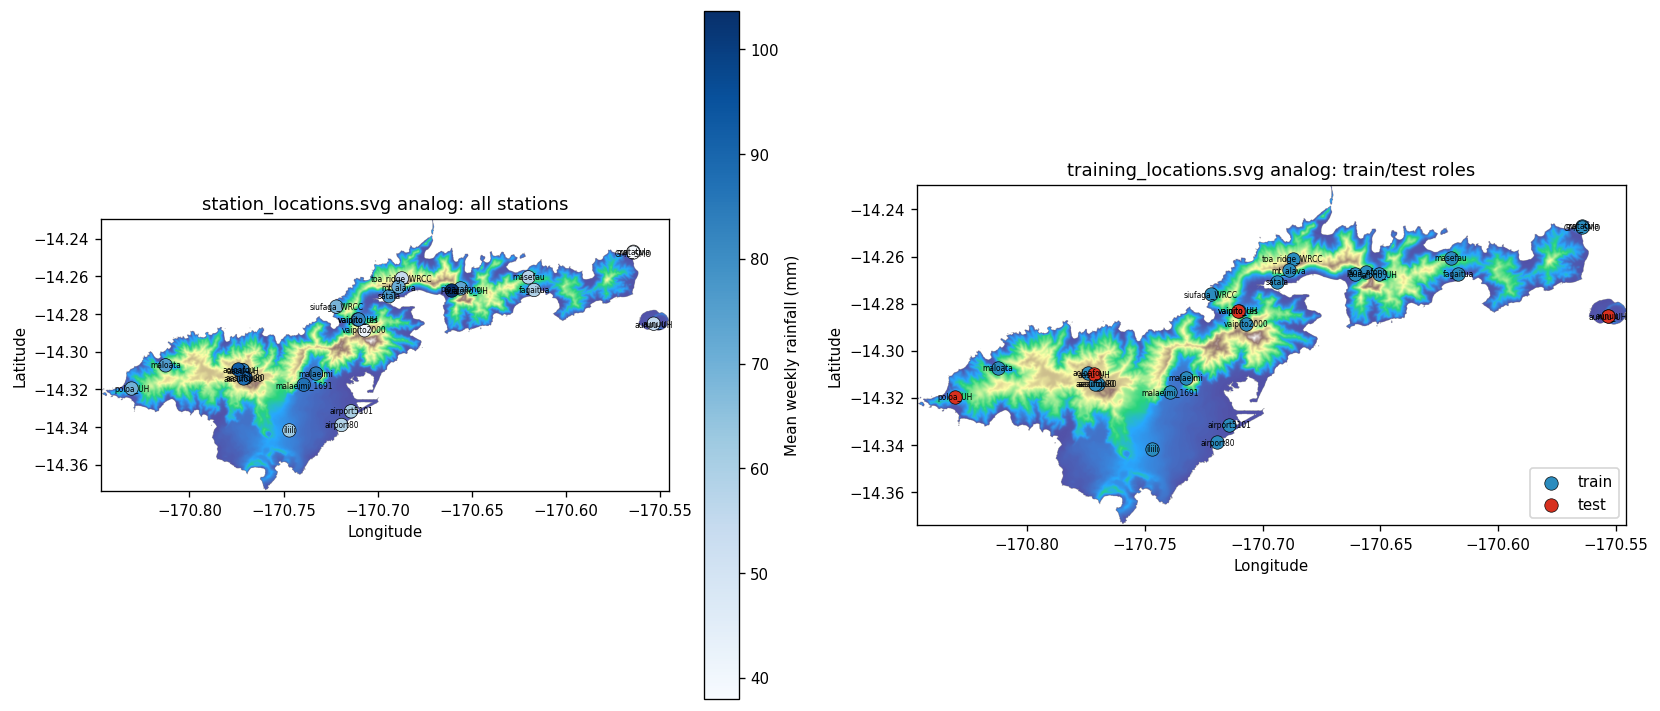

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
for ax, role_filter, title in [
    (axes[0], meta.index >= 0, 'station_locations.svg analog: all stations'),
    (axes[1], meta.index >= 0, 'training_locations.svg analog: train/test roles'),
]:
    ax.imshow(np.ma.masked_where(elev <= 0, elev), extent=extent, cmap='terrain', vmin=0, alpha=0.85)
    if ax is axes[0]:
        sc = ax.scatter(meta['lon'], meta['lat'], c=meta['mean_weekly_rain_mm'], cmap='Blues', s=65, edgecolor='k', linewidth=0.4)
        plt.colorbar(sc, ax=ax, label='Mean weekly rainfall (mm)')
    else:
        for role, color in [('train', '#2b8cbe'), ('test', '#d7301f')]:
            sub = meta[meta['role'] == role]
            ax.scatter(sub['lon'], sub['lat'], color=color, s=65, edgecolor='k', linewidth=0.4, label=role)
        ax.legend(loc='lower right')
    for _, row in meta.iterrows():
        ax.text(row['lon'], row['lat'], row['station'], fontsize=4.5, ha='center', va='center', color='black')
    ax.set_xlim(bounds.left, bounds.right); ax.set_ylim(bounds.bottom, bounds.top)
    ax.set_xlabel('Longitude'); ax.set_ylabel('Latitude'); ax.set_title(title)
plt.tight_layout()
fig.savefig(FIG_DIR / 'station_locations.svg', bbox_inches='tight')
fig.savefig(FIG_DIR / 'training_locations.svg', bbox_inches='tight')
plt.show()


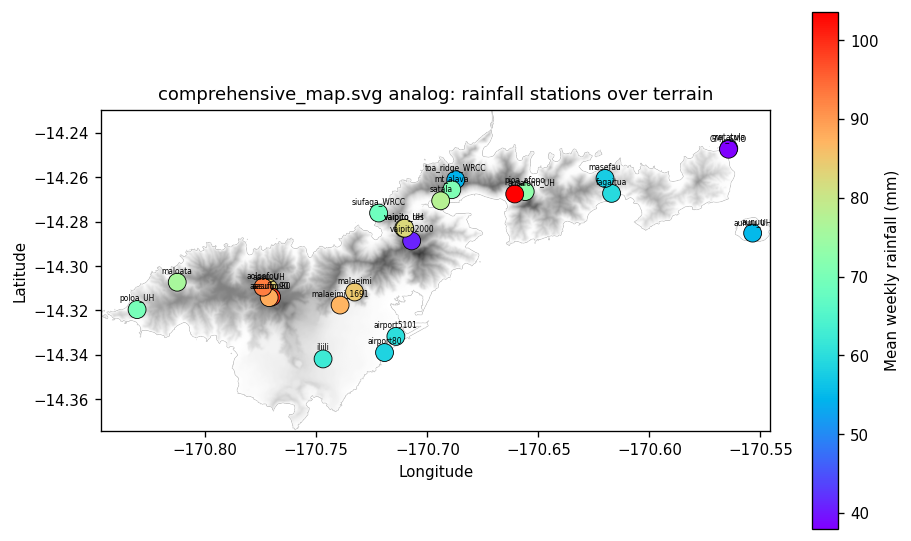

In [5]:
fig, ax = plt.subplots(figsize=(9, 7))
ax.imshow(np.ma.masked_where(elev <= 0, elev), extent=extent, cmap='gray_r', vmin=0, alpha=0.8)
sc = ax.scatter(meta['lon'], meta['lat'], c=meta['mean_weekly_rain_mm'], cmap='rainbow', s=115, edgecolor='k', linewidth=0.5)
for _, row in meta.iterrows():
    ax.text(row['lon'], row['lat'] + 0.004, row['station'], fontsize=4.5, ha='center')
cbar = plt.colorbar(sc, ax=ax, shrink=0.8)
cbar.set_label('Mean weekly rainfall (mm)')
ax.set_title('comprehensive_map.svg analog: rainfall stations over terrain')
ax.set_xlabel('Longitude'); ax.set_ylabel('Latitude')
fig.savefig(FIG_DIR / 'comprehensive_map.svg', bbox_inches='tight')
plt.show()


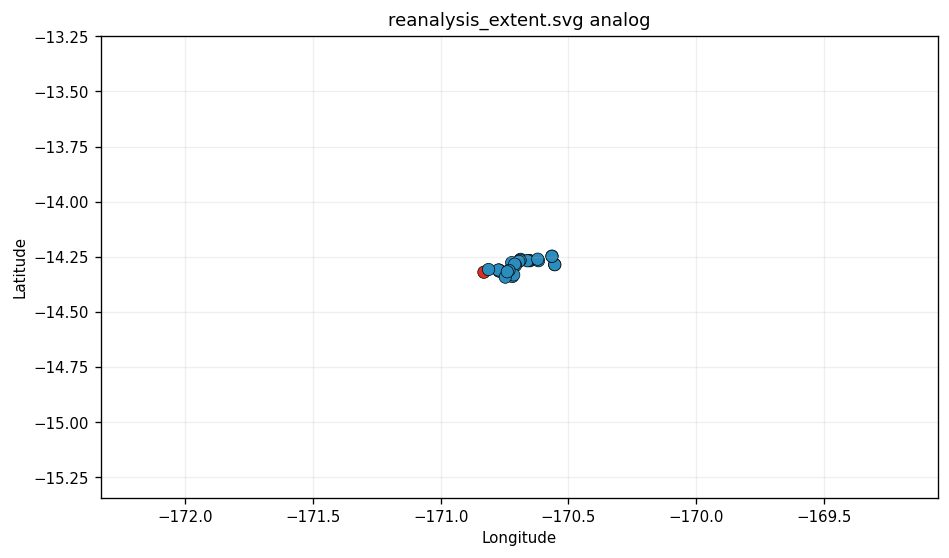

Reanalysis extent: -180.0 -160.0 -20.0 -10.0


In [6]:
nc_path = REPO_ROOT / 'raw_data' / 'AS' / 'climate_variables_daily_1980-2024' / 'air.2m.day.mean.nc'
ds = xr.open_dataset(nc_path)
lat_name = 'lat' if 'lat' in ds.coords else 'latitude'
lon_name = 'lon' if 'lon' in ds.coords else 'longitude'
lats = ds[lat_name].values
lons = ds[lon_name].values
lon0, lon1 = float(np.min(lons)), float(np.max(lons))
lat0, lat1 = float(np.min(lats)), float(np.max(lats))
if lon0 > 180:
    lons_plot = np.where(lons > 180, lons - 360, lons)
    lon0, lon1 = float(np.min(lons_plot)), float(np.max(lons_plot))
fig, ax = plt.subplots(figsize=(9, 5))
rect = plt.Rectangle((lon0, lat0), lon1-lon0, lat1-lat0, fill=False, edgecolor='#d62728', lw=2)
ax.add_patch(rect)
ax.scatter(meta['lon'], meta['lat'], c=np.where(meta['role'] == 'test', '#d7301f', '#2b8cbe'), s=55, edgecolor='k', linewidth=0.4)
ax.set_xlim(meta['lon'].min()-1.5, meta['lon'].max()+1.5)
ax.set_ylim(meta['lat'].min()-1.0, meta['lat'].max()+1.0)
ax.set_title('reanalysis_extent.svg analog')
ax.set_xlabel('Longitude'); ax.set_ylabel('Latitude')
ax.grid(alpha=0.2)
fig.savefig(FIG_DIR / 'reanalysis_extent.svg', bbox_inches='tight')
plt.show()
print('Reanalysis extent:', lon0, lon1, lat0, lat1)
ds.close()


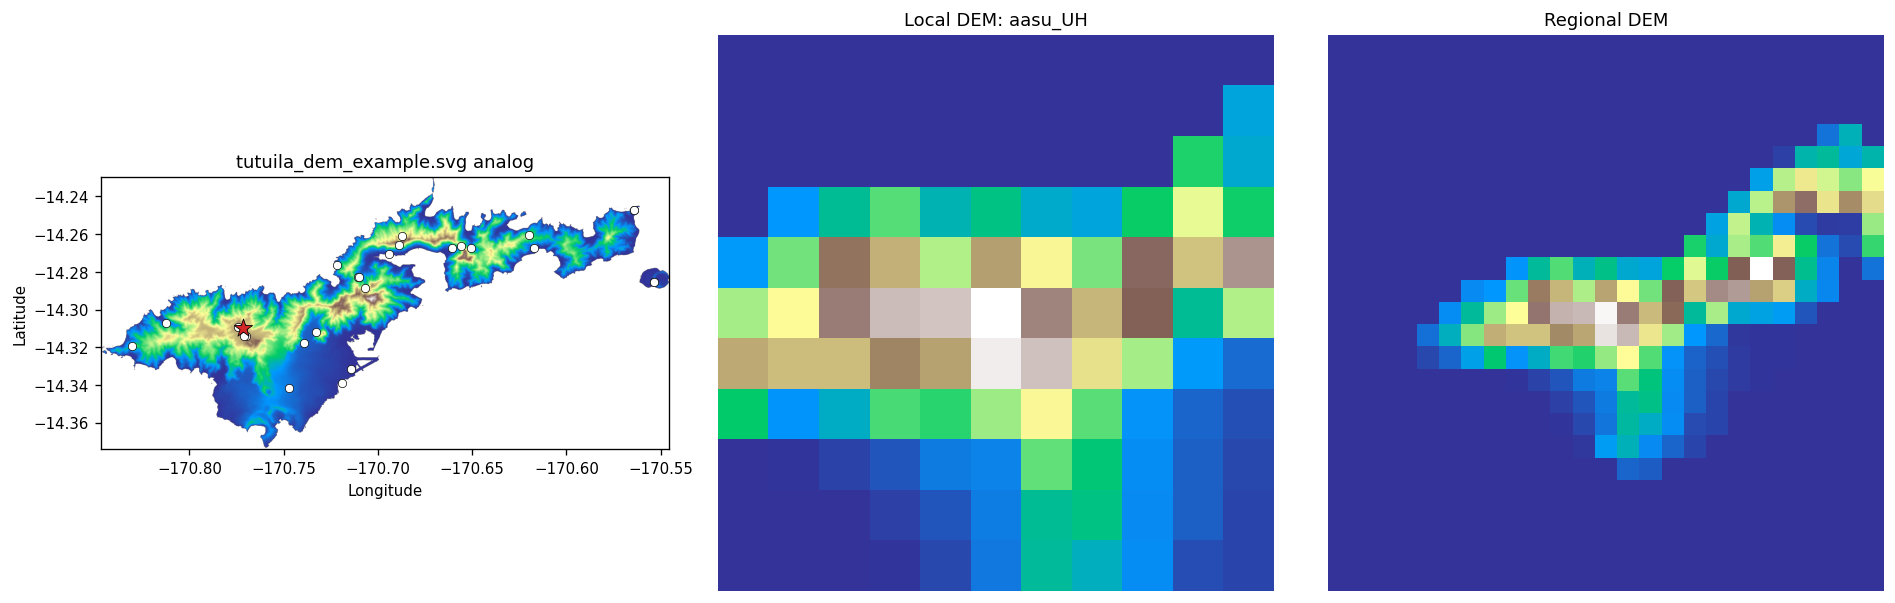

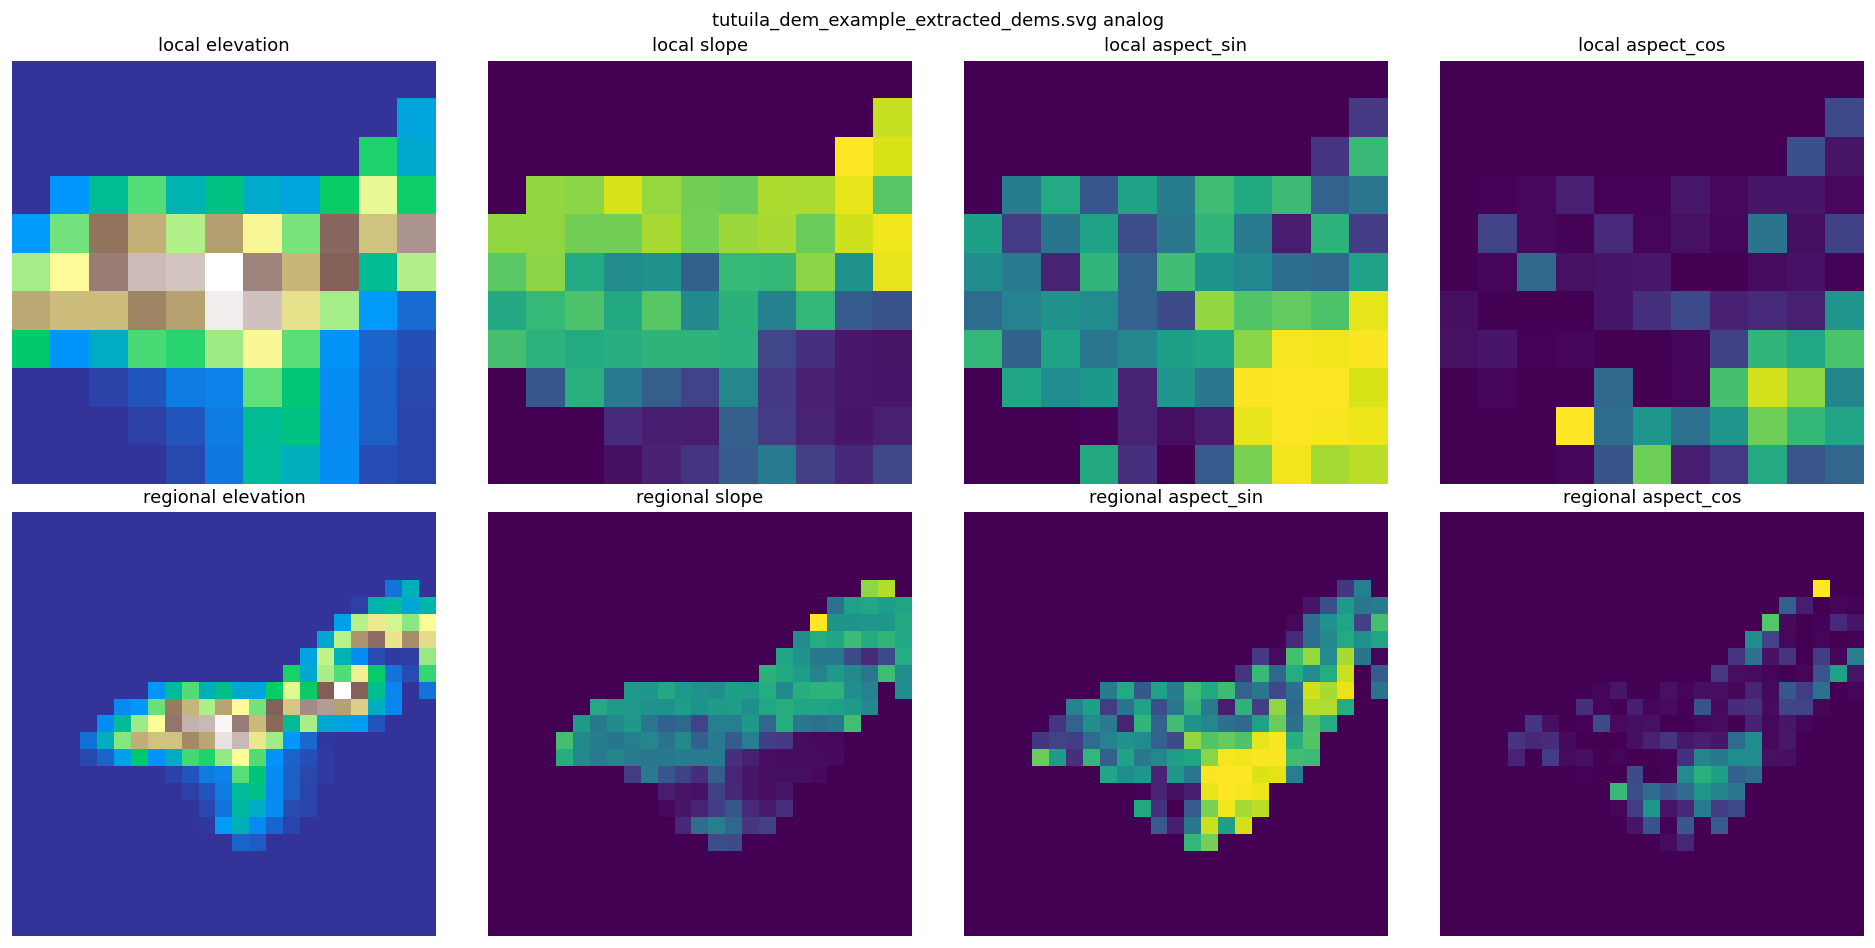

In [7]:
selected_station = 'aasu_UH'
row = meta[meta['station'] == selected_station].iloc[0]
dem_stations = dataset['dem_stations'].astype(str)
dem_idx = int(np.where(dem_stations == selected_station)[0][0])
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
axes[0].imshow(np.ma.masked_where(elev <= 0, elev), extent=extent, cmap='terrain', vmin=0)
axes[0].scatter(meta['lon'], meta['lat'], s=25, color='white', edgecolor='k', linewidth=0.4)
axes[0].scatter(row['lon'], row['lat'], s=130, marker='*', color='#d62728', edgecolor='k', linewidth=0.5)
axes[0].set_title('tutuila_dem_example.svg analog')
axes[0].set_xlabel('Longitude'); axes[0].set_ylabel('Latitude')
axes[1].imshow(dataset['dem_local_raw'][dem_idx, 0], cmap='terrain')
axes[1].set_title(f'Local DEM: {selected_station}')
axes[1].axis('off')
axes[2].imshow(dataset['dem_regional_raw'][dem_idx, 0], cmap='terrain')
axes[2].set_title('Regional DEM')
axes[2].axis('off')
plt.tight_layout()
fig.savefig(FIG_DIR / 'tutuila_dem_example.svg', bbox_inches='tight')
plt.show()

fig, axes = plt.subplots(2, 4, figsize=(16, 8))
bands = ['elevation', 'slope', 'aspect_sin', 'aspect_cos']
for b, name in enumerate(bands):
    axes[0, b].imshow(dataset['dem_local_raw'][dem_idx, b], cmap='terrain' if b == 0 else 'viridis')
    axes[0, b].set_title('local ' + name)
    axes[0, b].axis('off')
    axes[1, b].imshow(dataset['dem_regional_raw'][dem_idx, b], cmap='terrain' if b == 0 else 'viridis')
    axes[1, b].set_title('regional ' + name)
    axes[1, b].axis('off')
fig.suptitle('tutuila_dem_example_extracted_dems.svg analog')
plt.tight_layout()
fig.savefig(FIG_DIR / 'tutuila_dem_example_extracted_dems.svg', bbox_inches='tight')
plt.show()


## Historical climatology maps

The original repository maps gridded model output. Here the defensible analog is station climatology interpolated only over Tutuila land pixels. Observed climatology uses all available station records; the model panel uses the best retained scalar model's test predictions and therefore samples only the five test stations.


In [8]:
model_predictions = np.load(PACKAGE_DIR / 'output' / 'baselines' / 'model_predictions.npz', allow_pickle=True)
best_model = 'weekly_land_v5_huber_rw_msemon'
test_pred = model_predictions[f'pred_{best_model}']
test_obs = model_predictions['observed']
test_stations = model_predictions['stations'].astype(str)
test_years = model_predictions['years'].astype(int)
test_meta = pd.DataFrame({'station': test_stations, 'year': test_years, 'month': months[test_mask], 'obs': test_obs, 'pred': test_pred})

def season_frame(values_by_station):
    frame = meta.copy()
    frame['value'] = frame['station'].map(values_by_station)
    return frame.dropna(subset=['value'])

def idw_map(frame, power=2):
    lon_grid = np.linspace(bounds.left, bounds.right, width)
    lat_grid = np.linspace(bounds.bottom, bounds.top, height)
    gx, gy = np.meshgrid(lon_grid, lat_grid)
    pts = frame[['lon', 'lat']].values
    vals = frame['value'].values
    dist = np.sqrt((gx[..., None]-pts[:, 0])**2 + (gy[..., None]-pts[:, 1])**2)
    w = 1 / np.maximum(dist, 1e-5)**power
    out = (w * vals).sum(axis=2) / w.sum(axis=2)
    out[elev <= 0] = np.nan
    return out

wet_months = np.array([11, 12, 1, 2, 3, 4])
dry_months = np.array([5, 6, 7, 8, 9, 10])
obs_season = {}
model_season = {}
for season, month_set in [('wet', wet_months), ('dry', dry_months)]:
    m = np.isin(months, month_set)
    obs_season[season] = pd.DataFrame({'station': stations[m], 'rain': rain[m]}).groupby('station')['rain'].mean()
    tm = test_meta[test_meta['month'].isin(month_set)]
    model_season[season] = tm.groupby('station')['pred'].mean()
    fig, axes = plt.subplots(1, 2, figsize=(14, 6))
    for ax, values, title in [
        (axes[0], obs_season[season], 'observed station climatology'),
        (axes[1], model_season[season], f'{best_model} test climatology'),
    ]:
        frame = season_frame(values)
        z = idw_map(frame)
        im = ax.imshow(z, extent=extent, cmap='Blues', vmin=np.nanmin(z), vmax=np.nanmax(z))
        ax.scatter(frame['lon'], frame['lat'], c=frame['value'], cmap='Blues', edgecolor='k', s=45, vmin=np.nanmin(z), vmax=np.nanmax(z))
        ax.set_title(title)
        ax.set_xlabel('Longitude'); ax.set_ylabel('Latitude')
        plt.colorbar(im, ax=ax, label='Mean weekly rainfall (mm)')
    fig.suptitle(f'historical_climatology_{season}.svg analog')
    plt.tight_layout()
    fig.savefig(FIG_DIR / f'historical_climatology_observed_{season}.svg', bbox_inches='tight')
    plt.show()


KeyError: 'pred_weekly_land_v5_huber_rw_msemon is not a file in the archive'

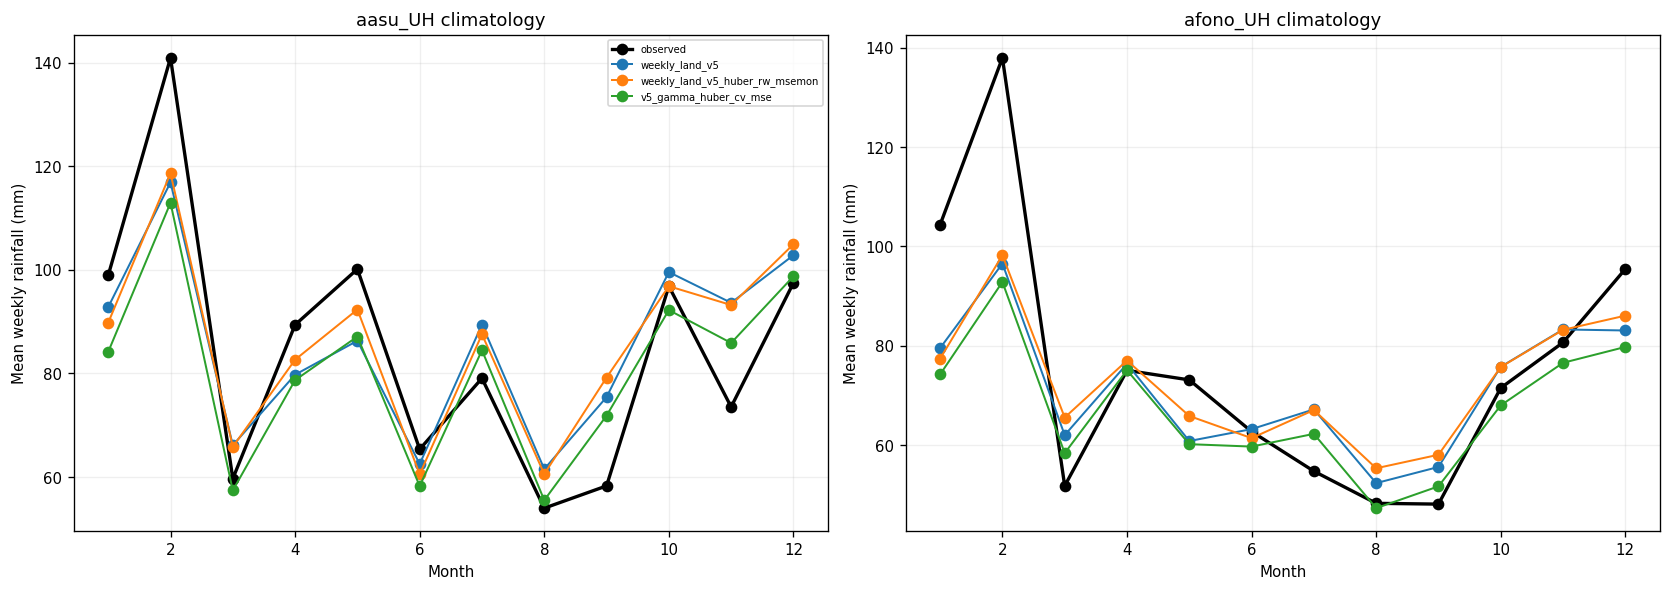

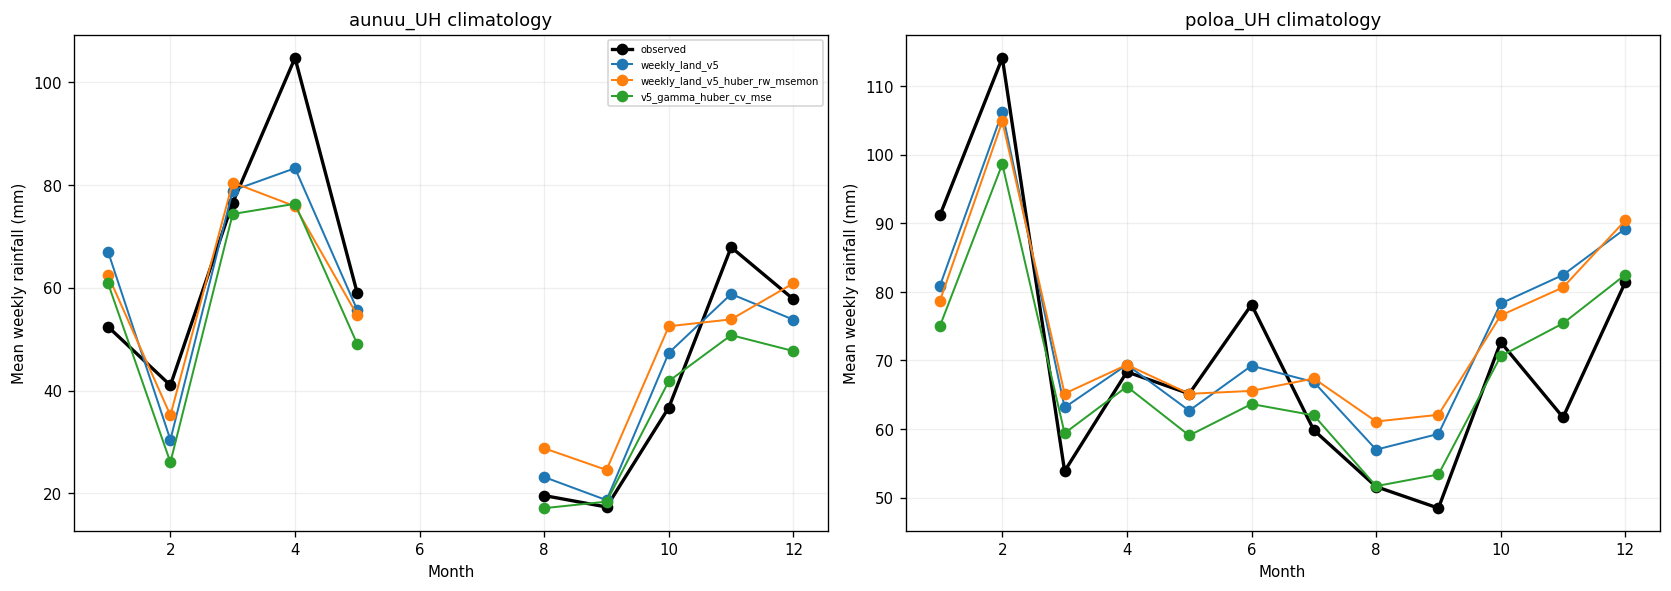

In [ ]:
selected_models = ['ridge', 'gbm', 'weekly_land_v5', best_model, 'v5_gamma_huber_cv_mse']
selected_models = [m for m in selected_models if f'pred_{m}' in model_predictions.files]
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, station in zip(axes, ['aasu_UH', 'afono_UH']):
    sub = test_meta[test_meta['station'] == station]
    ax.plot(np.arange(1, 13), sub.groupby('month')['obs'].mean().reindex(range(1, 13)), 'k-o', lw=2, label='observed')
    for model in selected_models:
        pred = model_predictions[f'pred_{model}']
        tmp = test_meta.copy(); tmp['pred_model'] = pred
        subm = tmp[tmp['station'] == station]
        ax.plot(np.arange(1, 13), subm.groupby('month')['pred_model'].mean().reindex(range(1, 13)), marker='o', lw=1.2, label=model)
    ax.set_title(f'{station} climatology')
    ax.set_xlabel('Month'); ax.set_ylabel('Mean weekly rainfall (mm)')
    ax.grid(alpha=0.2)
axes[0].legend(fontsize=6)
plt.tight_layout()
fig.savefig(FIG_DIR / 'Ia_climatology.svg', bbox_inches='tight')
plt.show()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, station in zip(axes, ['aunuu_UH', 'poloa_UH']):
    sub = test_meta[test_meta['station'] == station]
    ax.plot(np.arange(1, 13), sub.groupby('month')['obs'].mean().reindex(range(1, 13)), 'k-o', lw=2, label='observed')
    for model in selected_models:
        pred = model_predictions[f'pred_{model}']
        tmp = test_meta.copy(); tmp['pred_model'] = pred
        subm = tmp[tmp['station'] == station]
        ax.plot(np.arange(1, 13), subm.groupby('month')['pred_model'].mean().reindex(range(1, 13)), marker='o', lw=1.2, label=model)
    ax.set_title(f'{station} climatology')
    ax.set_xlabel('Month'); ax.set_ylabel('Mean weekly rainfall (mm)')
    ax.grid(alpha=0.2)
axes[0].legend(fontsize=6)
plt.tight_layout()
fig.savefig(FIG_DIR / 'IIa_climatology.svg', bbox_inches='tight')
plt.show()


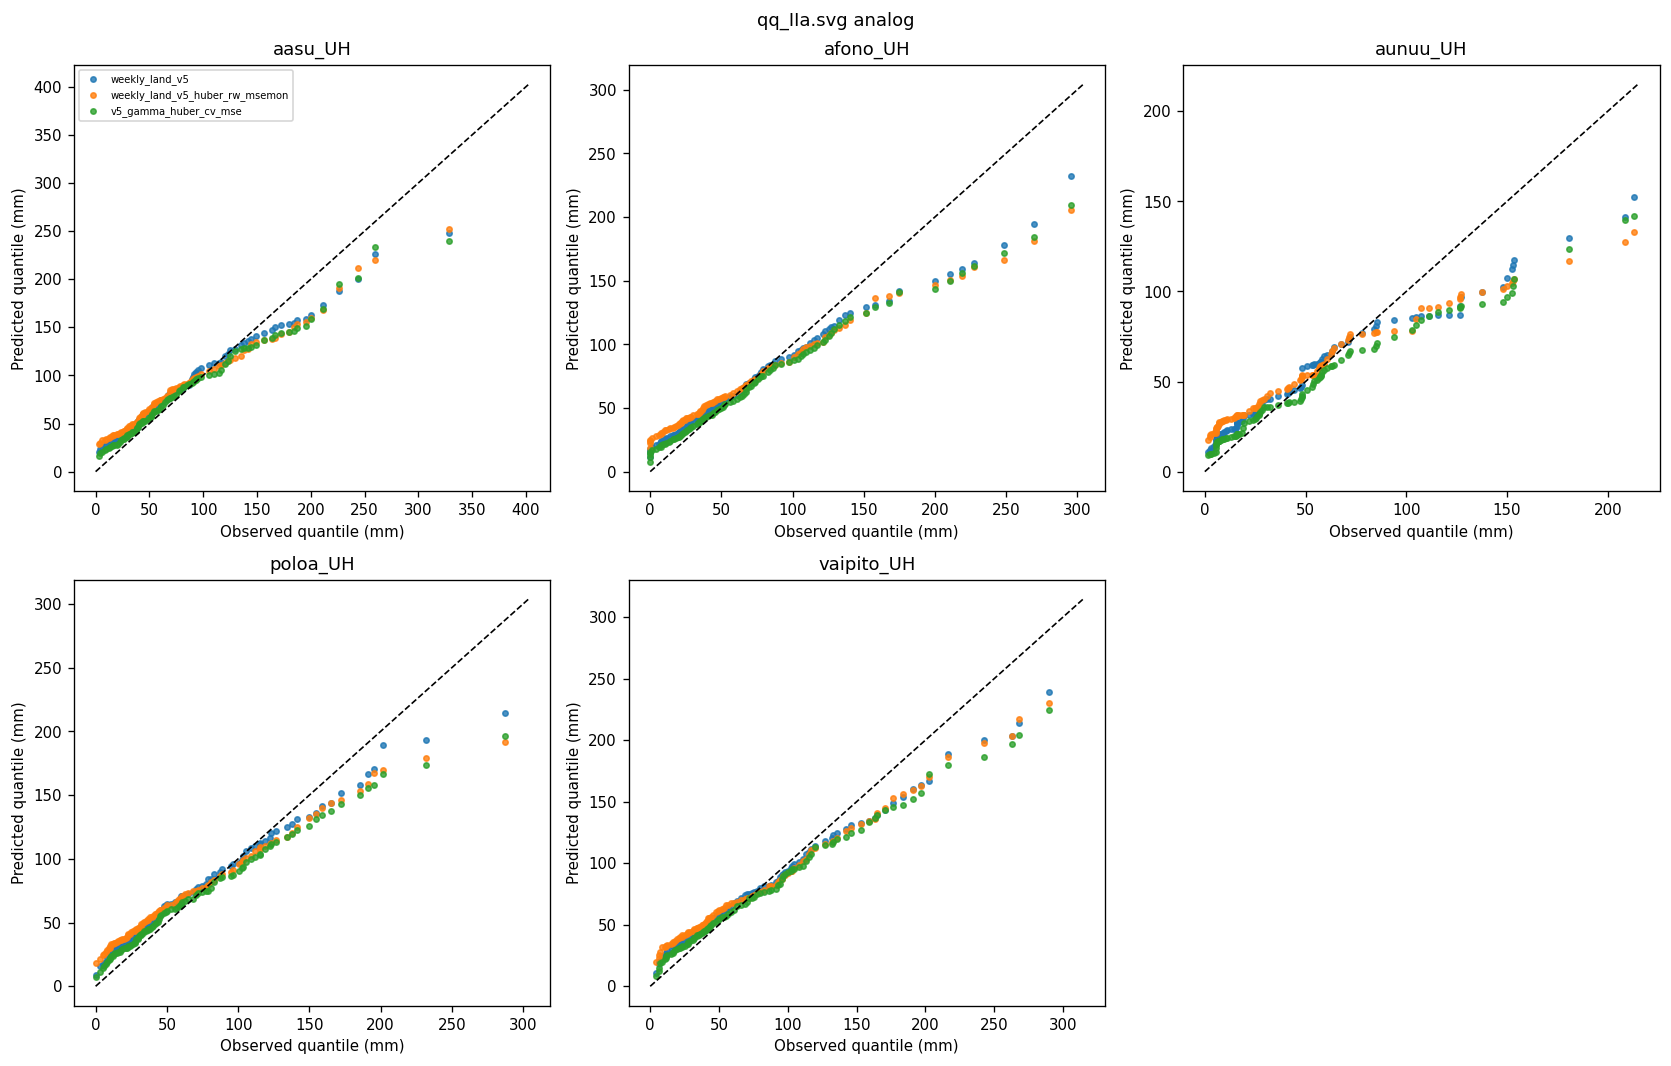

In [ ]:
fig, axes = plt.subplots(2, 3, figsize=(14, 9))
for ax, station in zip(axes.ravel(), sorted(set(test_stations))):
    mask = test_stations == station
    obs = test_obs[mask]
    qs = np.linspace(0.01, 0.99, 99)
    for model in selected_models:
        pred = model_predictions[f'pred_{model}'][mask]
        ax.scatter(np.quantile(obs, qs), np.quantile(pred, qs), s=10, alpha=0.8, label=model)
    lim = np.percentile(obs, 99.5)
    ax.plot([0, lim], [0, lim], 'k--', lw=1)
    ax.set_title(station)
    ax.set_xlabel('Observed quantile (mm)')
    ax.set_ylabel('Predicted quantile (mm)')
axes.ravel()[-1].axis('off')
axes[0, 0].legend(fontsize=6)
fig.suptitle('qq_IIa.svg analog')
plt.tight_layout()
fig.savefig(FIG_DIR / 'qq_IIa.svg', bbox_inches='tight')
plt.show()


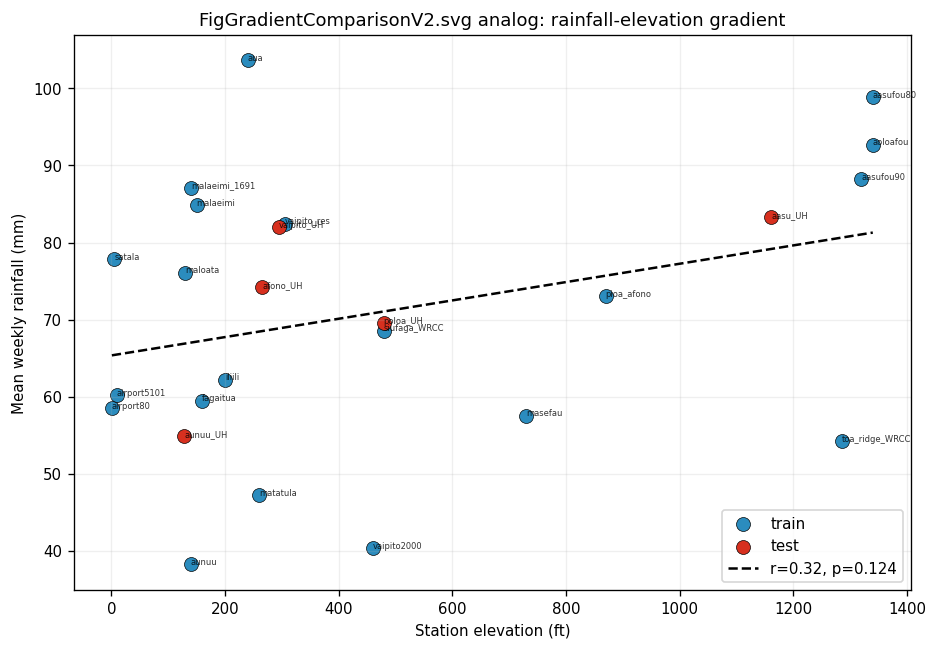

{'slope_mm_per_ft': np.float64(0.011897147145323245), 'r': np.float64(0.3157394918061269), 'p': np.float64(0.12416820186481596)}


In [ ]:
fig, ax = plt.subplots(figsize=(9, 6))
for role, color in [('train', '#2b8cbe'), ('test', '#d7301f')]:
    sub = meta[(meta['role'] == role) & meta['mean_weekly_rain_mm'].notna()]
    ax.scatter(sub['elevation_ft'], sub['mean_weekly_rain_mm'], color=color, s=70, edgecolor='k', linewidth=0.4, label=role)
    for _, row in sub.iterrows():
        ax.text(row['elevation_ft'], row['mean_weekly_rain_mm'], row['station'], fontsize=5, alpha=0.8)
fit = meta.dropna(subset=['elevation_ft', 'mean_weekly_rain_mm'])
slope, intercept, rvalue, pvalue, _ = linregress(fit['elevation_ft'], fit['mean_weekly_rain_mm'])
xx = np.linspace(fit['elevation_ft'].min(), fit['elevation_ft'].max(), 100)
ax.plot(xx, intercept + slope*xx, color='k', ls='--', label=f'r={rvalue:.2f}, p={pvalue:.3f}')
ax.set_title('FigGradientComparisonV2.svg analog: rainfall-elevation gradient')
ax.set_xlabel('Station elevation (ft)')
ax.set_ylabel('Mean weekly rainfall (mm)')
ax.legend()
ax.grid(alpha=0.2)
fig.savefig(FIG_DIR / 'FigGradientComparisonV2.svg', bbox_inches='tight')
plt.show()
print({'slope_mm_per_ft': slope, 'r': rvalue, 'p': pvalue})


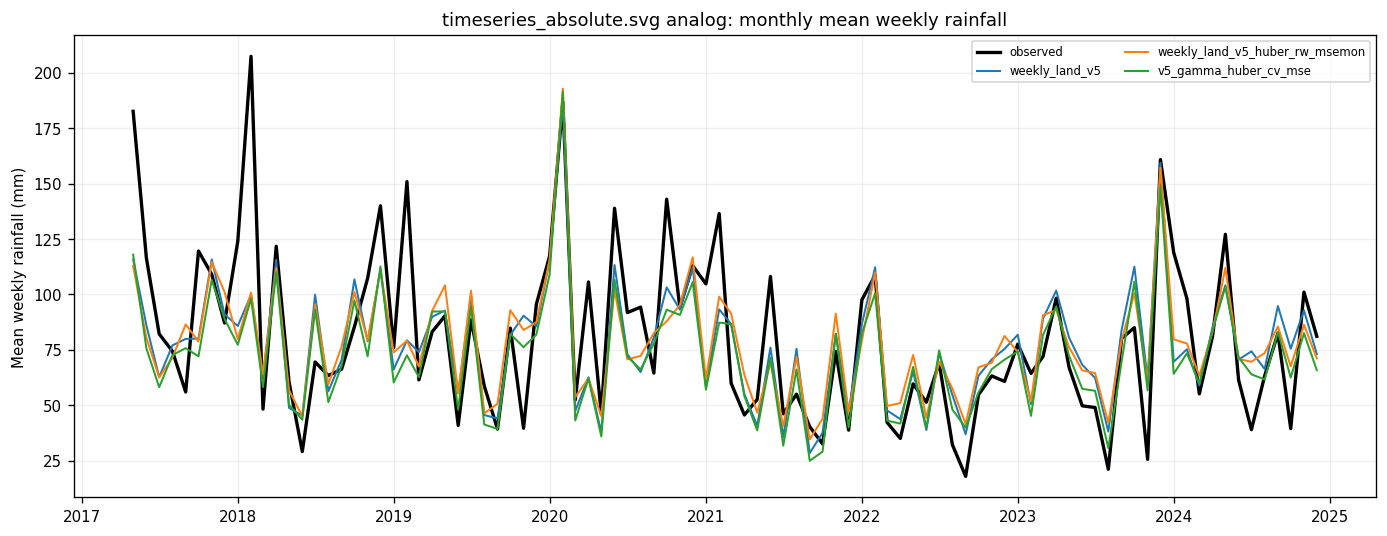

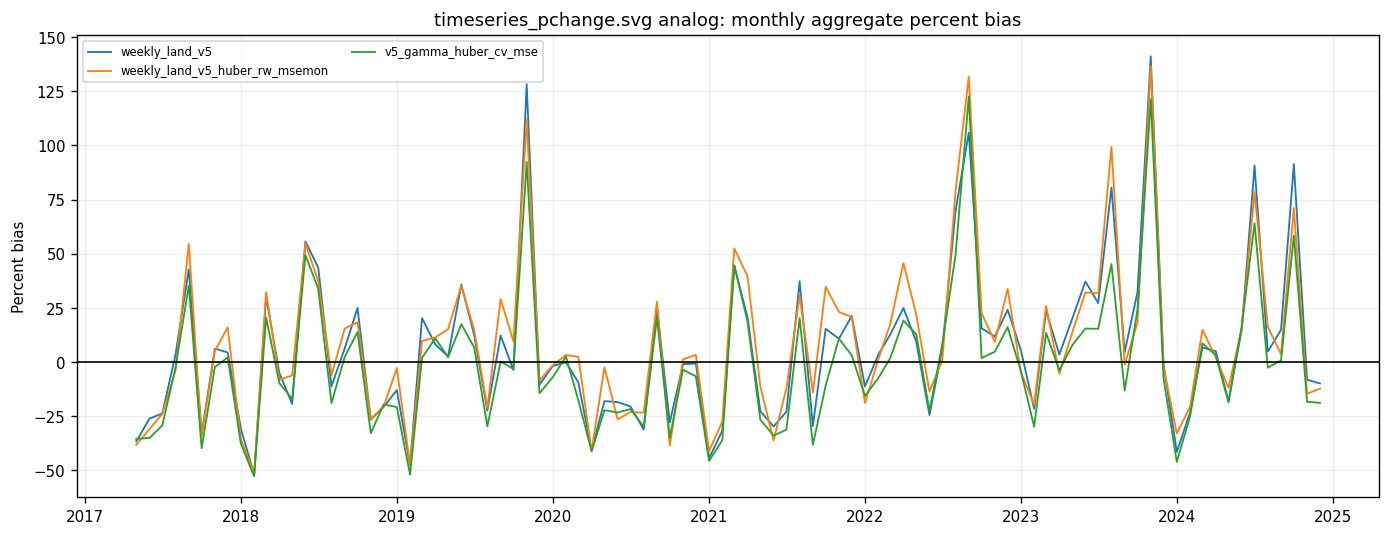

In [ ]:
test_meta['date'] = pd.to_datetime({'year': test_meta['year'], 'month': test_meta['month'], 'day': days[test_mask]})
for model in selected_models:
    test_meta[f'pred_{model}'] = model_predictions[f'pred_{model}']
monthly = test_meta.groupby(pd.Grouper(key='date', freq='MS'))[['obs'] + [f'pred_{m}' for m in selected_models]].mean()
fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(monthly.index, monthly['obs'], color='k', lw=2, label='observed')
for model in selected_models:
    ax.plot(monthly.index, monthly[f'pred_{model}'], lw=1.2, label=model)
ax.set_title('timeseries_absolute.svg analog: monthly mean weekly rainfall')
ax.set_ylabel('Mean weekly rainfall (mm)')
ax.legend(ncol=2, fontsize=7)
ax.grid(alpha=0.2)
fig.savefig(FIG_DIR / 'timeseries_absolute.svg', bbox_inches='tight')
plt.show()

fig, ax = plt.subplots(figsize=(14, 5))
for model in selected_models:
    pct = 100 * (monthly[f'pred_{model}'] - monthly['obs']) / monthly['obs'].replace(0, np.nan)
    ax.plot(monthly.index, pct, lw=1.1, label=model)
ax.axhline(0, color='k', lw=1)
ax.set_title('timeseries_pchange.svg analog: monthly aggregate percent bias')
ax.set_ylabel('Percent bias')
ax.legend(ncol=2, fontsize=7)
ax.grid(alpha=0.2)
fig.savefig(FIG_DIR / 'timeseries_pchange.svg', bbox_inches='tight')
plt.show()


In [ ]:
outputs = sorted(p.name for p in FIG_DIR.glob('*.svg'))
print('Generated files:')
for name in outputs:
    print(' ', name)
print('\nOriginal figure directory:', REPO_ROOT / 'LocationAgnosticNeuralDownscaling' / 'results' / 'figures')


Generated files:
  FigGradientComparisonV2.svg
  IIa_climatology.svg
  Ia_climatology.svg
  comprehensive_map.svg
  historical_climatology_observed_dry.svg
  historical_climatology_observed_wet.svg
  qq_IIa.svg
  reanalysis_extent.svg
  station_locations.svg
  timeseries_absolute.svg
  timeseries_pchange.svg
  training_locations.svg
  tutuila_dem_example.svg
  tutuila_dem_example_extracted_dems.svg

Original figure directory: C:\Users\JR\Documents\GitHub\AS_rainfall\LocationAgnosticNeuralDownscaling\results\figures
